-----------
Initializing structure...
time for choose_chunkdivision = 0.000130892 s
Working in 2D dimensions.
Computational cell is 16 x 8 x 0 with resolution 10
     block, center = (0,0,0)
          size (1e+20,1,1e+20)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (12,12,12)
time for set_epsilon = 0.021472 s
-----------
field decay(t = 50.050000000000004): 4.6179004623230974e-27 / 4.6179004623230974e-27 = 1.0
field decay(t = 100.05000000000001): 5.759488604525427e-21 / 5.759488604525427e-21 = 1.0
field decay(t = 150.1): 2.187328306694082e-19 / 2.187328306694082e-19 = 1.0
field decay(t = 200.15): 4.69348886692776e-19 / 4.69348886692776e-19 = 1.0
field decay(t = 250.20000000000002): 3.6752697591254896e-19 / 4.69348886692776e-19 = 0.7830570953354
field decay(t = 300.2): 2.0239400905425807e-19 / 4.69348886692776e-19 = 0.4312229447914726
field decay(t = 350.25): 1.996905338251718e-19 / 4.69348886692776e-19 = 0.42546289015890265
field decay(t = 

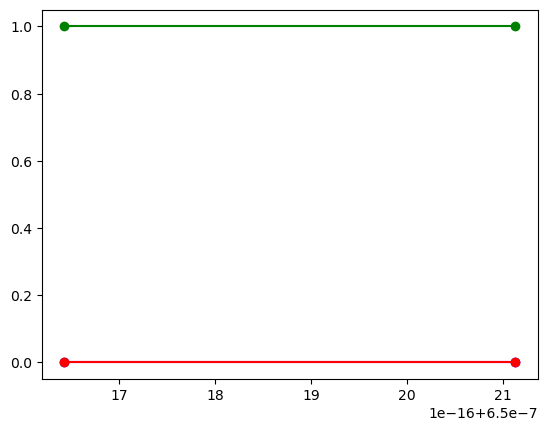

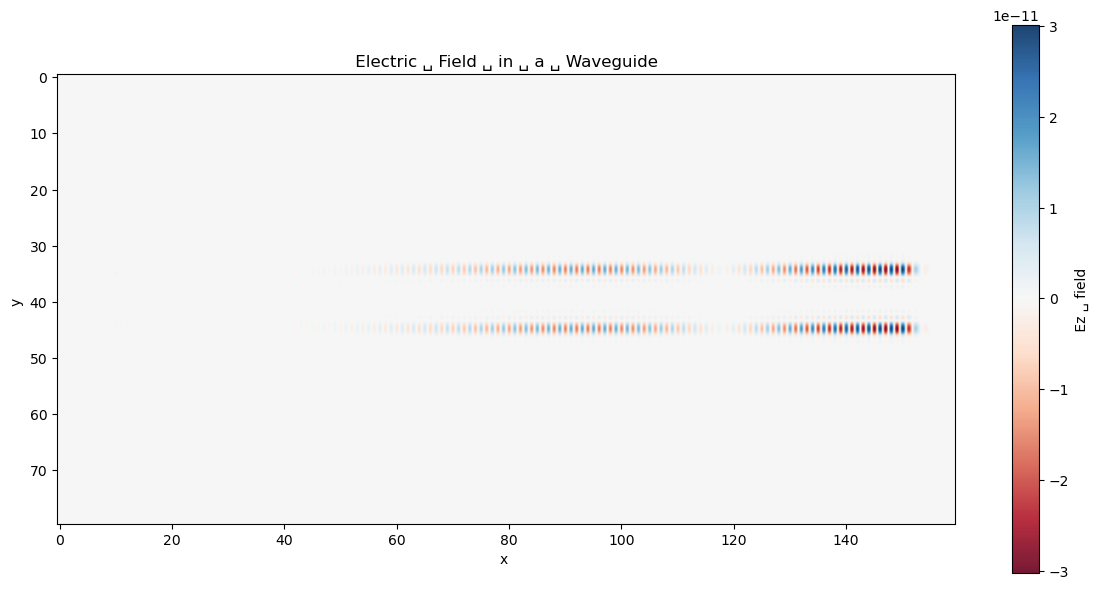

In [23]:
import meep as mp
import numpy as np
import matplotlib.pyplot as plt

resolution = 10 # pixels/um

sx = 16  # size of cell in X direction
sy = 8  # size of cell in Y direction
cell = mp.Vector3(sx,sy,0)

dpml = 1.0
pml_layers = [mp.PML(dpml)]

w = 1    # width of waveguide

geometry = [mp.Block(size=mp.Vector3(mp.inf,w,mp.inf),
                     center=mp.Vector3(0,0,0),
                     material=mp.Medium(epsilon=12))]

fcen = 1 / (650e-9)  # pulse center frequency
df = 1     # pulse width (in frequency)

sources = [mp.Source(mp.GaussianSource(fcen,fwidth=df),
                     component=mp.Ez,
                     center=mp.Vector3(-0.5*sx+dpml+0.5,0,0),
                     size=mp.Vector3(0,w,0))]

sim = mp.Simulation(cell_size=cell,
                    boundary_layers=pml_layers,
                    geometry=geometry,
                    sources=sources,
                    resolution=resolution)

nfreq = 2  # number of frequencies at which to compute flux

# reflected flux
refl_fr = mp.FluxRegion(center=mp.Vector3(-0.5*sx+dpml+1,0,0), size=mp.Vector3(0,2*w,0))
refl = sim.add_flux(fcen, df, nfreq, refl_fr)

# transmitted flux
tran_fr = mp.FluxRegion(center=mp.Vector3(0.5*sx-dpml-1,0,0), size=mp.Vector3(0,2*w,0))
tran = sim.add_flux(fcen, df, nfreq, tran_fr)
pt = mp.Vector3(0.5*sx-dpml-1.5,0)

sim.run(until_after_sources=mp.stop_when_fields_decayed(50,mp.Ez,pt,1e-3))

# for normalization run, save flux fields data for reflection plane
straight_refl_data = sim.get_flux_data(refl)

# save incident power for transmission plane
straight_tran_flux = mp.get_fluxes(tran)

ez_data = sim.get_array (
center = mp.Vector3 () ,
size = cell ,
component = mp.Ez
)

wl = []
Rs = []
Ts = []
for i in range(nfreq):
    wl = np.append(wl, 1/flux_freqs[i])
    Rs = np.append(Rs, straight_tran_flux[i])
    #Rs = np.append(Rs,-bend_refl_flux[i])
    Ts = np.append(Ts,straight_tran_flux[i])
plt.figure()
plt.plot(wl,Rs,'bo-',label='reflectance')
plt.plot(wl,Ts,'ro-',label='transmittance')
plt.plot(wl,1-Rs-Ts,'go-',label='loss')
plt.show()
plt.figure ( figsize =(12 , 6) )
plt.imshow ( ez_data.T , interpolation = 'spline36' ,
cmap = 'RdBu' , alpha =0.9)
plt.colorbar ( label = ' Ez ␣ field ')
plt.title ( ' Electric ␣ Field ␣ in ␣ a ␣ Waveguide ')
plt.xlabel ( 'x ')
plt.ylabel ( 'y ')
plt.tight_layout ()
plt.show ()

sim.reset_meep()


-----------
Initializing structure...
time for choose_chunkdivision = 0.000138998 s
Working in 2D dimensions.
Computational cell is 16 x 8 x 0 with resolution 10
     block, center = (0,0,0)
          size (6,6,1e+20)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (12,12,12)
     block, center = (5,-2,0)
          size (4,1,1e+20)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (12,12,12)
     block, center = (5,2,0)
          size (4,1,1e+20)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (12,12,12)
     block, center = (-5,0,0)
          size (4,1,1e+20)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (12,12,12)
time for set_epsilon = 0.031286 s
-----------
field decay(t = 50.050000000000004): 5.163394954864126e-28 / 5.163394954864126e-28 = 1.0
field decay(t = 100.05000000000001): 3.9821810898230915e-22 / 3.982181089

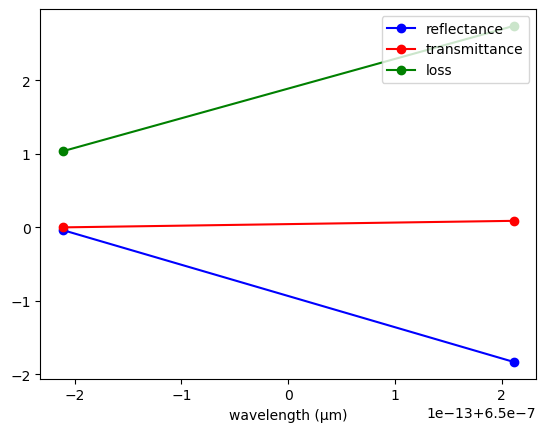

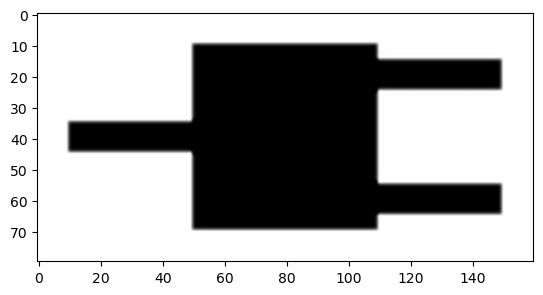

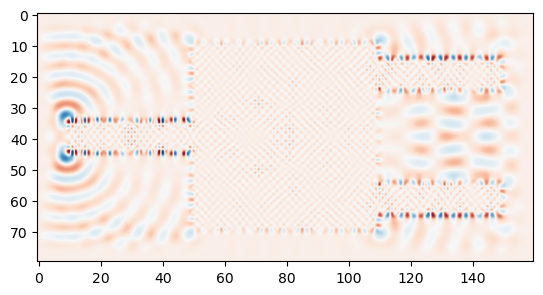

In [24]:
sources = [mp.Source(mp.GaussianSource(fcen,fwidth=df),
                     component=mp.Ez,
                     center=mp.Vector3(-0.5*sx+dpml+0.5,0,0),
                     size=mp.Vector3(0,w,0))]

geometry = [mp.Block (
                        center = mp.Vector3 (0 , 0 , 0) ,
                        size = mp.Vector3 ( w*6, w*6, mp . inf ) ,
                        material = mp.Medium ( epsilon =12)
                        ),
           mp.Block (
                        center = mp.Vector3 ( 5 , -2 , 0) ,
                        size = mp.Vector3 ( w*4 , w , mp . inf ) ,
                        material = mp.Medium ( epsilon =12)
                        ),
           mp.Block (
                        center = mp.Vector3 ( 5 , 2 , 0) ,
                        size = mp.Vector3 ( w*4 , w , mp . inf ) ,
                        material = mp.Medium ( epsilon =12)
                        ), 
           mp.Block (
                        center = mp.Vector3 (-5 , 0 , 0) ,
                        size = mp.Vector3 ( w*4 , w , mp . inf ) ,
                        material = mp.Medium ( epsilon =12)
                        )]

sim = mp.Simulation(cell_size=cell,
                    boundary_layers=pml_layers,
                    geometry=geometry,
                    sources=sources,
                    resolution=resolution)

# reflected flux
refl_fr = mp.FluxRegion(center=mp.Vector3(-0.5*sx+dpml+1,0,0), size=mp.Vector3(0,2*w,0))
refl = sim.add_flux(fcen, df, nfreq, refl_fr)

tran_fr = mp.FluxRegion(center=mp.Vector3(0.5*sx-dpml-1,2,0), size=mp.Vector3(0,2*w,0))
tran = sim.add_flux(fcen, df, nfreq, tran_fr)

# for normal run, load negated fields to subtract incident from refl. fields
sim.load_minus_flux_data(refl, straight_refl_data)

pt = mp.Vector3(0.5*sx-dpml-1.5,2)

sim.run(until_after_sources=mp.stop_when_fields_decayed(50, mp.Ez, pt, 1e-3))

bend_refl_flux = mp.get_fluxes(refl)
bend_tran_flux = mp.get_fluxes(tran)

flux_freqs = mp.get_flux_freqs(refl)
eps_data = sim.get_array(center=mp.Vector3(), size=cell, component=mp.Dielectric)
ez_data = sim.get_array (center = mp.Vector3 () ,size = cell ,component = mp.Ez)

wl = []
Rs = []
Ts = []
for i in range(nfreq):
    wl = np.append(wl, 1/flux_freqs[i])
    Rs = np.append(Rs,-bend_refl_flux[i]/straight_tran_flux[i])
    #Rs = np.append(Rs,-bend_refl_flux[i])
    Ts = np.append(Ts,bend_tran_flux[i]/straight_tran_flux[i])


if mp.am_master():
    plt.figure()
    plt.plot(wl,Rs,'bo-',label='reflectance')
    plt.plot(wl,Ts,'ro-',label='transmittance')
    plt.plot(wl,1-Rs-Ts,'go-',label='loss')
    plt.xlabel("wavelength (μm)")
    plt.legend(loc="upper right")
    plt.show()
    plt.imshow(eps_data.transpose(), interpolation='spline36', cmap='binary')
    plt.show()
    plt.imshow ( ez_data.T , interpolation = 'spline36' ,
cmap = 'RdBu' , alpha =0.9)
    plt.show()